In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_1 = "E:/IAD/Intern/16_CMAPSS_using_Transformer/data/train_FD001.txt"
train_2 = "E:/IAD/Intern/16_CMAPSS_using_Transformer/data/train_FD002.txt"
train_3 = "E:/IAD/Intern/16_CMAPSS_using_Transformer/data/train_FD003.txt"
train_4 = "E:/IAD/Intern/16_CMAPSS_using_Transformer/data/train_FD004.txt"

rul_1 = "E:/IAD/Intern/16_CMAPSS_using_Transformer/data/RUL_FD001.txt"
rul_2 = "E:/IAD/Intern/16_CMAPSS_using_Transformer/data/RUL_FD002.txt"
rul_3 = "E:/IAD/Intern/16_CMAPSS_using_Transformer/data/RUL_FD003.txt"
rul_4 = "E:/IAD/Intern/16_CMAPSS_using_Transformer/data/RUL_FD004.txt"

## train 1

In [ ]:
index_names = ['ID Engine', 'Cycle']
setting_names = ['Setting 1', 'Setting 2', 'Setting 3']
sensor_names = ['Sensor {}'.format(i) for i in range(1, 22)]
column_names = index_names + setting_names + sensor_names

train_1 = pd.read_csv(train_1, sep=' ', header=None)
train_1.drop([26, 27], axis=1, inplace=True)
train_1.columns = column_names

train_1['Remaining RUL'] = ''

max_cycle = train_1.groupby('ID Engine').count()
max_cycle.iloc[:, 0:1]

train_1.head()

,ID Engine,Cycle,Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Remaining RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,


In [5]:
# remaining_rul = max_rul - cycle
for idx in range(len(train_1)):
    train_1.loc[idx, 'Remaining RUL'] = max_cycle.loc[train_1.loc[idx, 'ID Engine'], 'Cycle']

In [6]:
train_1['Remaining RUL'] = train_1['Remaining RUL'] - train_1['Cycle']

In [7]:
train_1 = train_1.drop(['Setting 1','Setting 2', 'Sensor 1', 'Setting 3','Sensor 5','Sensor 6', 'Sensor 10', 'Sensor 16', 'Sensor 18','Sensor 19'], axis=1)
train_1.head()

,ID Engine,Cycle,Sensor 2,Sensor 3,Sensor 4,Sensor 7,Sensor 8,Sensor 9,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 17,Sensor 20,Sensor 21,Remaining RUL
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


# Transformer by Tensorflow

In [ ]:
import tensorflow as tf
import keras
from keras import layers

class TransformerModel(tf.keras.Model):
    def __init__(self):
        super(TransformerModel, self).__init__()
        
        self.conv1d = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')
        self.layer_norm1 = layers.LayerNormalization()
        
        # Transformer encoder block
        self.multi_head_attention = layers.MultiHeadAttention(num_heads=4, key_dim=64)
        self.dropout1 = layers.Dropout(0.1)
        self.layer_norm2 = layers.LayerNormalization()
        
        self.dense1 = layers.Dense(128, activation='relu')
        self.dropout2 = layers.Dropout(0.1)
        self.dense2 = layers.Dense(64)
        self.layer_norm3 = layers.LayerNormalization()
        
        self.global_avg_pool = layers.GlobalAveragePooling1D()
        self.dense3 = layers.Dense(64, activation='relu')
        self.dropout3 = layers.Dropout(0.1)
        self.output_layer = layers.Dense(1, activation='linear')

    def call(self, inputs, training=False):
        x = self.conv1d(inputs)
        x = self.layer_norm1(x)
        
        attention_output = self.multi_head_attention(x, x)
        attention_output = self.dropout1(attention_output, training=training)
        attention_output = self.layer_norm2(attention_output + x)
        
        feed_forward = self.dense1(attention_output)
        feed_forward = self.dropout2(feed_forward, training=training)
        feed_forward_resized = self.dense2(feed_forward)
        x = self.layer_norm3(feed_forward_resized + attention_output)
        
        x = self.global_avg_pool(x)
        x = self.dense3(x)
        x = self.dropout3(x, training=training)
        return self.output_layer(x)

In [82]:
# Usage
input_shape = (30, 14)
model = TransformerModel(input_shape)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# model.build((None,) + input_shape)
model.summary()

Model: "transformer_model_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_13 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_37          │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_head_attention_12         │ ?                      │   0 (unbuilt) │
│ (MultiHeadAttention)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_38          │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_39          │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_9      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [78]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


# Normalize features
# scaler = MinMaxScaler()
features = ['Sensor 2', 'Sensor 3', 'Sensor 4',	'Sensor 7',	'Sensor 8',	'Sensor 9',	'Sensor 11', 'Sensor 12', 'Sensor 13', 'Sensor 14',	'Sensor 15', 'Sensor 17', 'Sensor 20', 'Sensor 21']
# train_1[features] = scaler.fit_transform(train_1[features])

def create_sequences(data, sequence_length=30):
    sequences = []
    targets = []
    for engine_id, engine_data in data.groupby('ID Engine'):
        for i in range(len(engine_data) - sequence_length):
            seq = engine_data.iloc[i:i+sequence_length][features].values
            target = engine_data.iloc[i+sequence_length]['Remaining RUL']
            sequences.append(seq)
            targets.append(target)
    return np.array(sequences), np.array(targets)

sequence_length = 30
X, y = create_sequences(train_1, sequence_length)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [80]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Test MAE: {mae}")

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - loss: 8798.2930 - mae: 73.9562 - val_loss: 3735.4893 - val_mae: 49.8561
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 3872.6221 - mae: 50.4855 - val_loss: 3735.2244 - val_mae: 49.8608
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 3821.1328 - mae: 50.5642 - val_loss: 3738.2935 - val_mae: 50.0653
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 3845.7678 - mae: 50.5584 - val_loss: 3736.0688 - val_mae: 50.0186
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 3850.1570 - mae: 50.3264 - val_loss: 3734.2283 - val_mae: 49.9615
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 3919.7642 - mae: 51.1129 - val_loss: 3733.8354 - val_mae: 49.9393
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - loss: 3822.1897 - mae: 50.4270 - val_loss: 3741.0386 - val_mae: 50.1107
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - loss: 3940.4517 - mae: 51.2138 - val_loss: 3733.

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


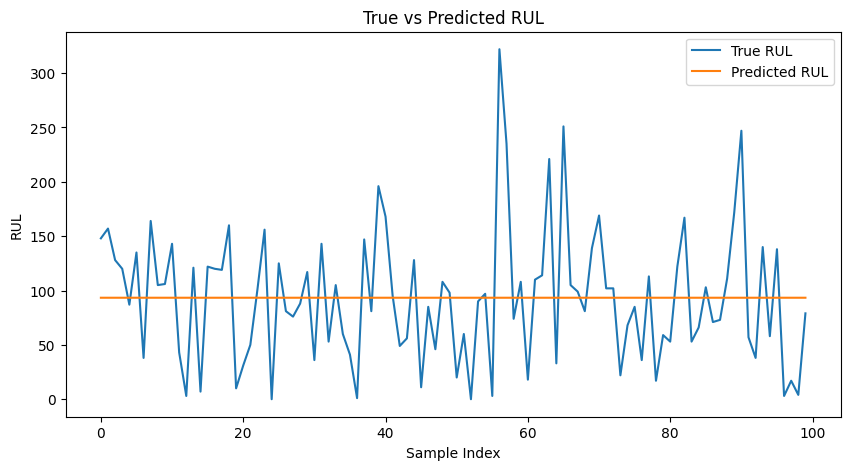

In [81]:
# Predict RUL
y_pred = model.predict(X_test)

# Visualize results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test[:100], label="True RUL")
plt.plot(y_pred[:100], label="Predicted RUL")
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("RUL")
plt.title("True vs Predicted RUL")
plt.show()
